In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow_datasets as tfds   # ← replaces emnist package

print("TensorFlow:", tf.__version__)
print("All imports done ✅")

2026-06-05 03:32:28.998096: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780630349.524620      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780630349.666632      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780630350.875672      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780630350.875717      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780630350.875720      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
All imports done ✅


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST train: (60000, 28, 28)
MNIST test:  (10000, 28, 28)
Labels:      [0 1 2 3 4 5 6 7 8 9]


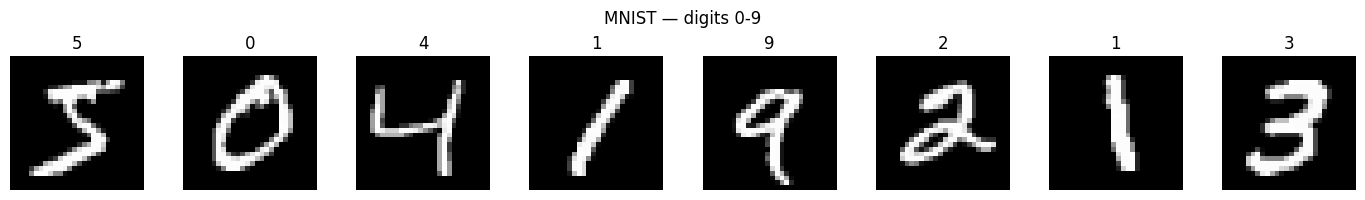

In [2]:
(X_mnist_train, y_mnist_train), (X_mnist_test, y_mnist_test) = mnist.load_data()

print("MNIST train:", X_mnist_train.shape)  # (60000, 28, 28)
print("MNIST test: ", X_mnist_test.shape)   # (10000, 28, 28)
print("Labels:     ", np.unique(y_mnist_train))  # [0 1 2 ... 9]

# Visualize a few MNIST digits
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_mnist_train[i], cmap='gray')
    ax.set_title(str(y_mnist_train[i]))
    ax.axis('off')
plt.suptitle('MNIST — digits 0-9', fontsize=12)
plt.tight_layout()
plt.show()


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

I0000 00:00:1780630381.536213      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780630381.542285      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.OS1953_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.OS1953_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
Converting training set... (takes ~1 min)
Converting test set...
EMNIST train: (88800, 28, 28)
EMNIST test:  (14800, 28, 28)
Labels range: 1 to 26
Remapped labels: 10 to 35


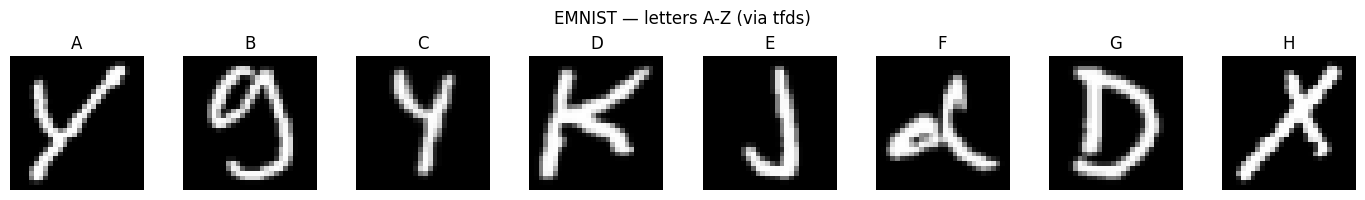

EMNIST loaded ✅


In [3]:
# Load EMNIST letters via tensorflow_datasets
ds_train = tfds.load('emnist/letters', split='train', as_supervised=True)
ds_test  = tfds.load('emnist/letters', split='test',  as_supervised=True)

# Convert tf.Dataset → numpy arrays
def dataset_to_numpy(ds):
    images, labels = [], []
    for img, lbl in tfds.as_numpy(ds):
        images.append(img[:, :, 0])   # shape (28,28,1) → (28,28)
        labels.append(lbl)
    return np.array(images), np.array(labels)

print("Converting training set... (takes ~1 min)")
X_em_train, y_em_train = dataset_to_numpy(ds_train)

print("Converting test set...")
X_em_test, y_em_test = dataset_to_numpy(ds_test)

print("EMNIST train:", X_em_train.shape)
print("EMNIST test: ", X_em_test.shape)
print("Labels range:", y_em_train.min(), "to", y_em_train.max())  # 1 to 26

# Fix orientation (EMNIST images are transposed vs MNIST)
X_em_train = np.transpose(X_em_train, (0, 2, 1))
X_em_test  = np.transpose(X_em_test,  (0, 2, 1))

# Remap labels: 1–26 → 10–35
# So: 0-9 = digits, 10-35 = A-Z
y_em_train = y_em_train + 9
y_em_test  = y_em_test  + 9

print("Remapped labels:", y_em_train.min(), "to", y_em_train.max())

# Visualize a few letters
LETTERS = 'ABCDEFGH'
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_em_train[i], cmap='gray')
    ax.set_title(LETTERS[i])
    ax.axis('off')
plt.suptitle('EMNIST — letters A-Z (via tfds)', fontsize=12)
plt.tight_layout()
plt.show()

print("EMNIST loaded ✅")

In [4]:
# ── Combine ───────────────────────────────────────────────────
X_train_raw = np.concatenate([X_mnist_train, X_em_train], axis=0)
X_test_raw  = np.concatenate([X_mnist_test,  X_em_test],  axis=0)
y_train     = np.concatenate([y_mnist_train, y_em_train], axis=0)
y_test      = np.concatenate([y_mnist_test,  y_em_test],  axis=0)

print("Combined train:", X_train_raw.shape)  # (184800, 28, 28)
print("Combined test: ", X_test_raw.shape)   # (24800, 28, 28)
print("Total classes: ", len(np.unique(y_train)))  # 36

# ── Normalize: 0-255 → 0.0-1.0 ───────────────────────────────
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0

# ── Reshape: add channel dim for Conv2D ───────────────────────
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print("\nFinal X_train:", X_train.shape)   # (184800, 28, 28, 1)
print("Final X_test: ", X_test.shape)     # (30800, 28, 28, 1)
print("y_train range:", y_train.min(), "to", y_train.max())  # 0 to 35

# Label map for display (36 classes)
LABEL_MAP = {i: str(i) for i in range(10)}
LABEL_MAP.update({i+10: chr(65+i) for i in range(26)})
# {0:'0', 1:'1'..9:'9', 10:'A', 11:'B'...35:'Z'}
print("\nLabel map sample:", {k: LABEL_MAP[k] for k in [0,5,9,10,15,35]})

Combined train: (148800, 28, 28)
Combined test:  (24800, 28, 28)
Total classes:  36

Final X_train: (148800, 28, 28, 1)
Final X_test:  (24800, 28, 28, 1)
y_train range: 0 to 35

Label map sample: {0: '0', 5: '5', 9: '9', 10: 'A', 15: 'F', 35: 'Z'}


In [5]:
model = keras.Sequential([

    # Add explicit Input layer — removes the UserWarning
    keras.Input(shape=(28, 28, 1)),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(36, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,380 (1.62 MB)

 Trainable params: 425,380 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,             # More epochs for harder 36-class problem
    batch_size=128,        # Larger batch for larger dataset
    validation_split=0.1,
    verbose=1
)

print("\nTraining complete ✅")

Epoch 1/10


I0000 00:00:1780630483.188256      76 service.cc:152] XLA service 0x7f3380003740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780630483.188290      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780630483.188293      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780630483.697041      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


  28/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0677 - loss: 3.4927

I0000 00:00:1780630488.264400      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1047/1047 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.7858 - loss: 0.7313 - val_accuracy: 0.8913 - val_loss: 0.3209
Epoch 2/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9188 - loss: 0.2639 - val_accuracy: 0.9191 - val_loss: 0.2551
Epoch 3/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9360 - loss: 0.2053 - val_accuracy: 0.9229 - val_loss: 0.2341
Epoch 4/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9449 - loss: 0.1750 - val_accuracy: 0.9292 - val_loss: 0.2211
Epoch 5/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9515 - loss: 0.1518 - val_accuracy: 0.9309 - val_loss: 0.2162
Epoch 6/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9543 - loss: 0.1398 - val_accuracy: 0.9334 - val_loss: 0.2028
Epoch 7/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9580 - loss: 0.1262 - val_accuracy: 0.9358 - val_loss: 0.2001
Epoch 8/10
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9614 - loss: 0.1169 - val_accura

In [7]:
model.save('cnn_handwriting_model.keras')
print("Model saved ✅")

Model saved ✅


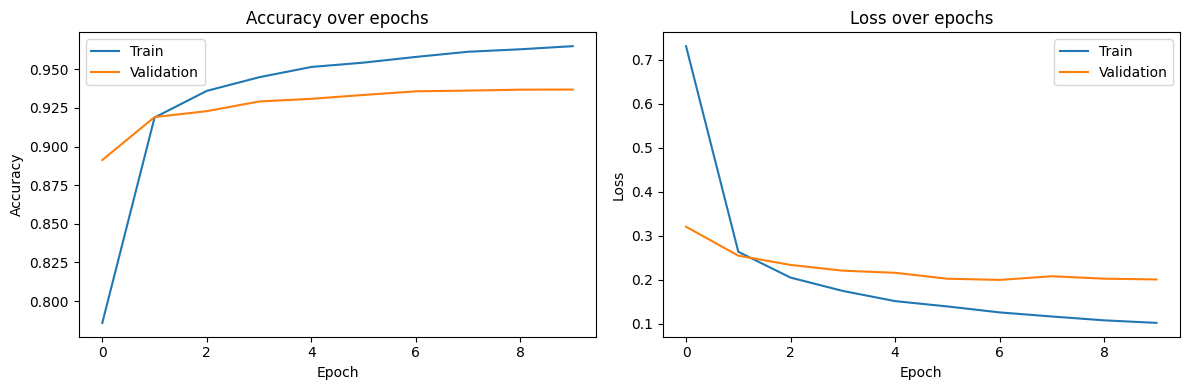

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Verify label map covers your actual range
print("y_test unique labels:", np.unique(y_test))
print("LABEL_MAP keys:", sorted(LABEL_MAP.keys()))

# If any mismatch, rebuild it:
LABEL_MAP = {i: str(i) for i in range(10)}
LABEL_MAP.update({i+10: chr(65+i) for i in range(26)})
print("Label map:", LABEL_MAP)

y_test unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28]
LABEL_MAP keys: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Label map: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'}


Test accuracy: 95.27%
Test loss:     0.1419
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


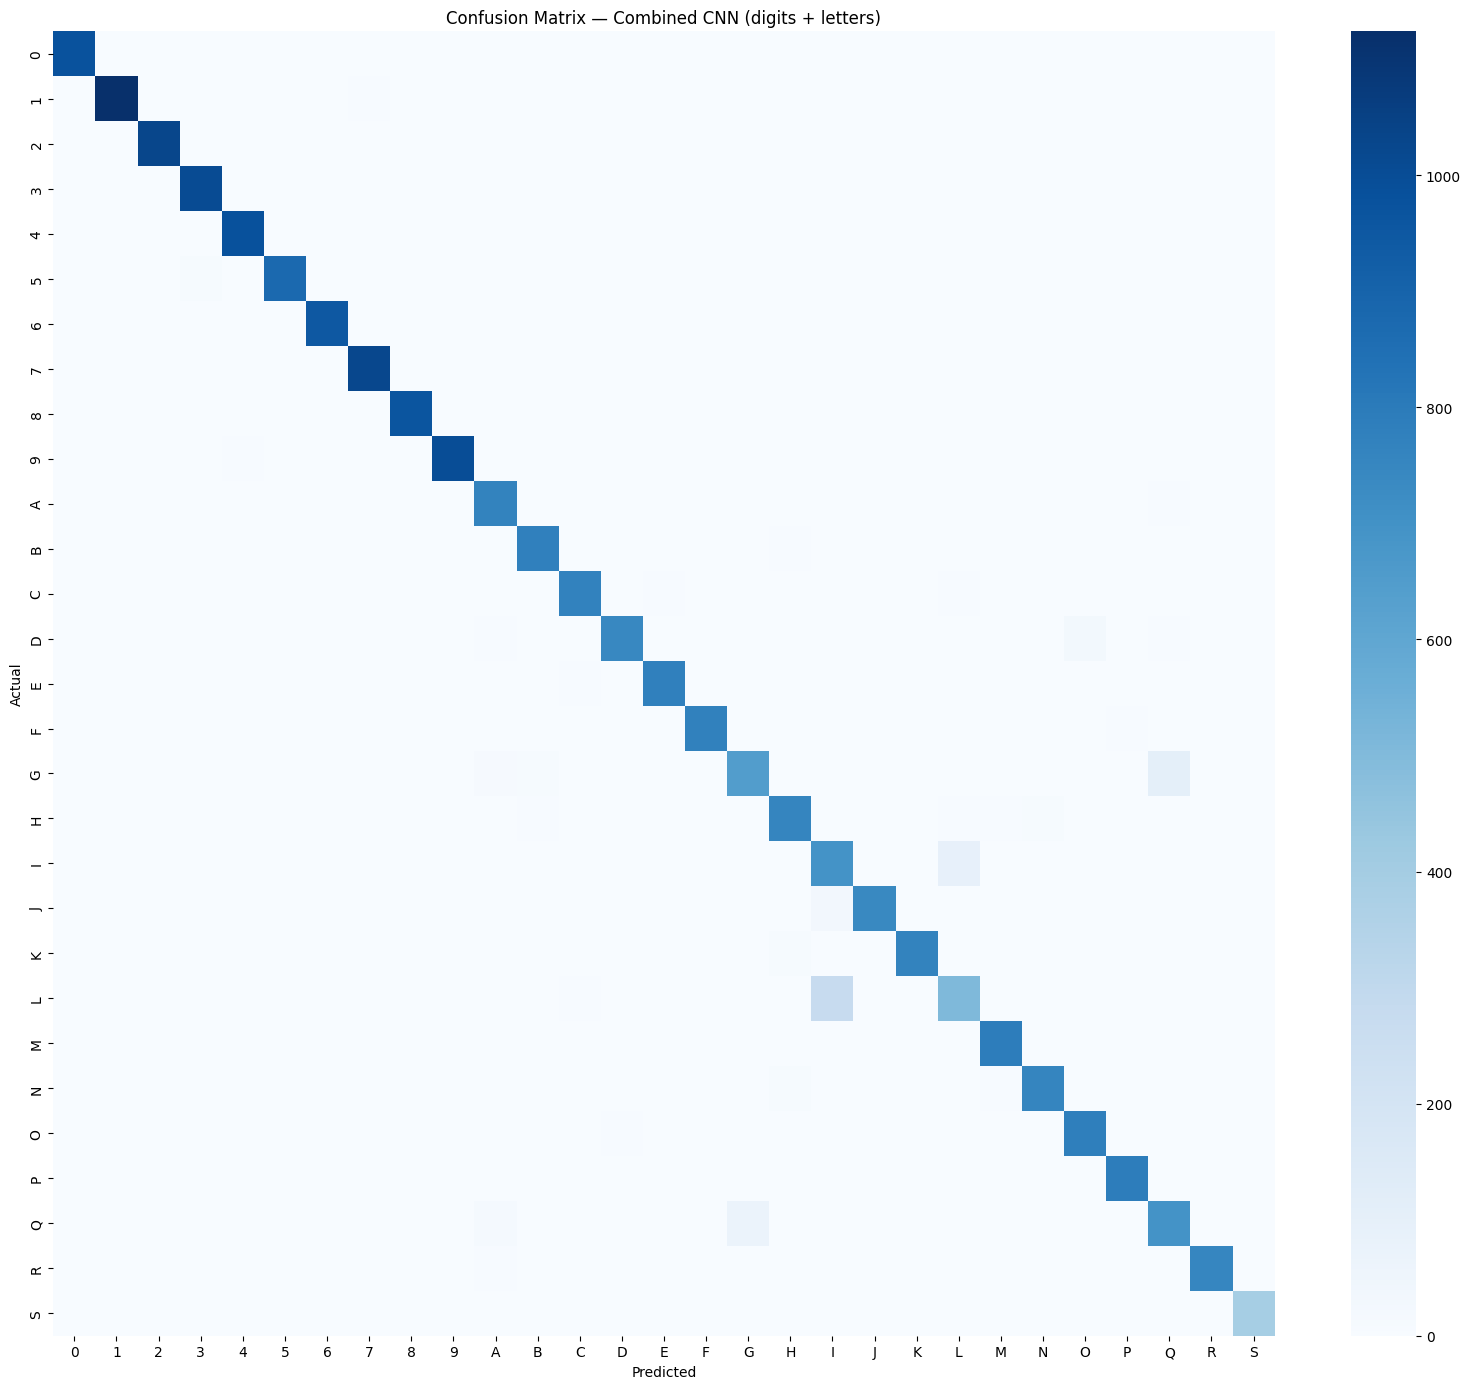

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.98      1.00      0.99       982
           5       1.00      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009
           A       0.92      0.96      0.94       800
           B       0.96      0.97      0.97       800
           C       0.98      0.96      0.97       800
           D       0.98      0.93      0.95       800
           E       0.97      0.97      0.97       800
           F       0.99      0.97      0.98       800
           G       0.89      0.81      0.85       800
           H       0.95    

In [10]:
actual_labels = sorted(np.unique(y_test))
actual_names  = [LABEL_MAP[l] for l in actual_labels]

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Test loss:     {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)

plt.figure(figsize=(16, 14))
cm = confusion_matrix(y_test, y_pred, labels=actual_labels)
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=actual_names,
            yticklabels=actual_names)
plt.title('Confusion Matrix — Combined CNN (digits + letters)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred,
      labels=actual_labels,
      target_names=actual_names,
      zero_division=0))

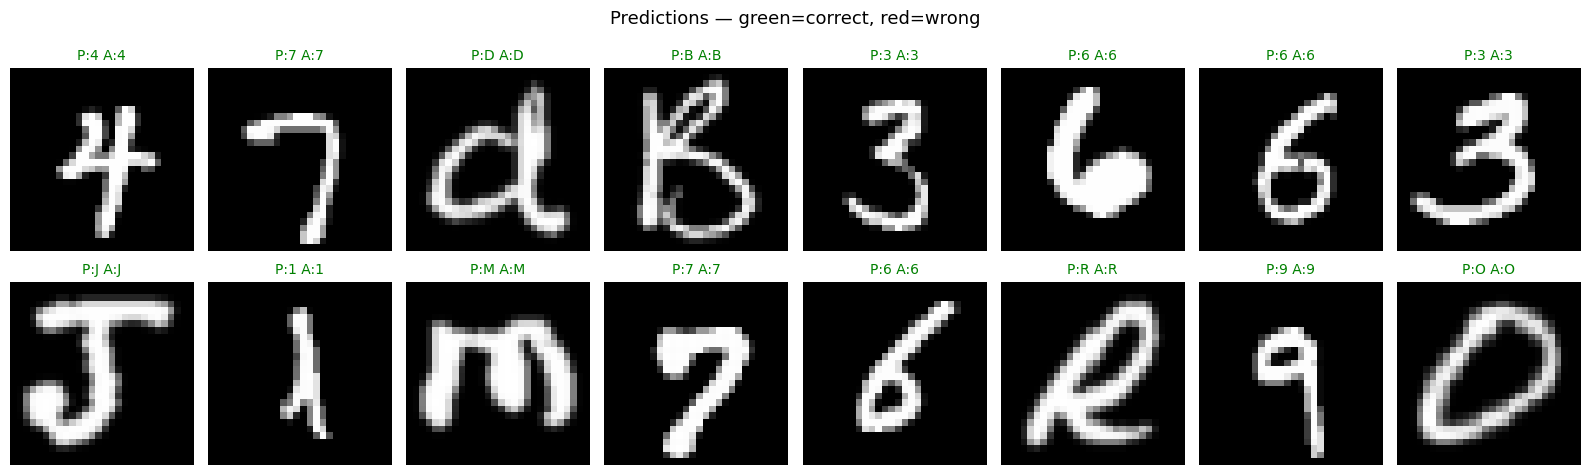

In [11]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
indices = np.random.choice(len(X_test), 16, replace=False)

for i, (ax, idx) in enumerate(zip(axes.flat, indices)):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    pred   = LABEL_MAP[y_pred[idx]]
    actual = LABEL_MAP[y_test[idx]]
    color  = 'green' if pred == actual else 'red'
    ax.set_title(f"P:{pred} A:{actual}", color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('Predictions — green=correct, red=wrong', fontsize=13)
plt.tight_layout()
plt.show()

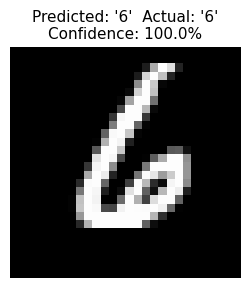

Top 5 predictions:
  6: 100.00%
  5: 0.00%
  0: 0.00%
  G: 0.00%
  8: 0.00%


In [12]:
idx = np.random.randint(len(X_test))
sample = X_test[idx]
actual = LABEL_MAP[y_test[idx]]

proba  = model.predict(sample[np.newaxis, ...], verbose=0)[0]
pred   = LABEL_MAP[np.argmax(proba)]
conf   = proba.max() * 100

plt.figure(figsize=(3, 3))
plt.imshow(sample.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: '{pred}'  Actual: '{actual}'\nConfidence: {conf:.1f}%",
          fontsize=11)
plt.axis('off')
plt.show()

# Top 5 predictions
top5_idx  = proba.argsort()[-5:][::-1]
print("Top 5 predictions:")
for i in top5_idx:
    print(f"  {LABEL_MAP[i]}: {proba[i]*100:.2f}%")